In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Dict, List, Optional

import os
import json
import numpy as np
import pandas as pd

import logging

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
# Create logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [ ]:
# Import datasets
TRAIN = '../data/breast-cancer-diagnostic.shuf.lrn.csv'
TEST = '../data/breast-cancer-diagnostic.shuf.tes.csv'
SOL_EXP = '../data/breast-cancer-diagnostic.shuf.sol.ex.csv'

df_train = pd.read_csv(TRAIN)
df_test = pd.read_csv(TEST)
df_solution = pd.read_csv(SOL_EXP)

In [ ]:
# Display dataset shapes 
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (285, 32)
Test shape: (284, 31)


In [ ]:
# Display first few rows of the training dataset
display(df_train.head())

,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8813129,False,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.024560,...,15.14,23.60,98.84,708.8,0.1276,0.1311,0.17860,0.09678,0.2506,0.07623
1,898678,False,12.06,18.90,76.66,445.3,0.08386,0.05794,0.00751,0.008488,...,13.64,27.06,86.54,562.6,0.1289,0.1352,0.04506,0.05093,0.2880,0.08083
2,917896,False,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.037830,...,15.11,25.63,99.43,701.9,0.1425,0.2566,0.19350,0.12840,0.2849,0.09031
3,869691,True,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.074150,...,13.74,26.38,91.93,591.7,0.1385,0.4092,0.45040,0.18650,0.5774,0.10300
4,9110127,True,18.03,16.85,117.50,990.0,0.08947,0.12320,0.10900,0.062540,...,20.38,22.02,133.30,1292.0,0.1263,0.2666,0.42900,0.15350,0.2842,0.08225


In [12]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       285 non-null    int64  
 1   class                    285 non-null    bool   
 2   radiusMean               285 non-null    float64
 3    textureMean             285 non-null    float64
 4    perimeterMean           285 non-null    float64
 5    areaMean                285 non-null    float64
 6    smoothnessMean          285 non-null    float64
 7    compactnessMean         285 non-null    float64
 8    concavityMean           285 non-null    float64
 9    concavePointsMean       285 non-null    float64
 10   symmetryMean            285 non-null    float64
 11   fractalDimensionMean    285 non-null    float64
 12   radiusStdErr            285 non-null    float64
 13   textureStdErr           285 non-null    float64
 14   perimeterStdErr         2

In [13]:
missing = df_train.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

In [14]:
df_train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ID,285.0,2.861498e+07,1.204247e+08,8670.000,871149.000,906539.000,8811523.000,9.113205e+08
radiusMean,285.0,1.406900e+01,3.486000e+00,6.981,11.690,13.280,16.070,2.742000e+01
textureMean,285.0,1.911600e+01,4.517000e+00,10.380,15.900,18.700,21.840,3.928000e+01
perimeterMean,285.0,9.155500e+01,2.402900e+01,43.790,74.680,86.100,105.800,1.869000e+02
areaMean,285.0,6.496180e+02,3.439790e+02,143.500,418.700,546.400,797.800,2.501000e+03
smoothnessMean,285.0,9.600000e-02,1.400000e-02,0.053,0.086,0.095,0.105,1.630000e-01
compactnessMean,285.0,1.030000e-01,5.100000e-02,0.019,0.062,0.092,0.130,3.450000e-01
concavityMean,285.0,8.600000e-02,7.600000e-02,0.000,0.027,0.062,0.123,4.110000e-01
concavePointsMean,285.0,4.800000e-02,3.700000e-02,0.000,0.021,0.033,0.073,1.690000e-01
symmetryMean,285.0,1.830000e-01,2.900000e-02,0.122,0.162,0.181,0.198,3.040000e-01


In [23]:
# --- Diagnose: finde die Spalte mit Zielwerten ---

# 1. Zeige alle Spaltennamen
print("Columns:", list(df_train.columns))
print()

# 2. Zeige die ersten Zeilen (damit du siehst, wo das Label steht)
df_train.head()


Columns: ['ID', 'class', 'radiusMean', ' textureMean', ' perimeterMean', ' areaMean', ' smoothnessMean', ' compactnessMean', ' concavityMean', ' concavePointsMean', ' symmetryMean', ' fractalDimensionMean', ' radiusStdErr', ' textureStdErr', ' perimeterStdErr', ' areaStdErr', ' smoothnessStdErr', ' compactnessStdErr', ' concavityStdErr', ' concavePointsStdErr', ' symmetryStdErr', ' fractalDimensionStdErr', ' radiusWorst', ' textureWorst', ' perimeterWorst', ' areaWorst', ' smoothnessWorst', ' compactnessWorst', ' concavityWorst', ' concavePointsWorst', ' symmetryWorst', ' fractalDimensionWorst']



,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8813129,False,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.024560,...,15.14,23.60,98.84,708.8,0.1276,0.1311,0.17860,0.09678,0.2506,0.07623
1,898678,False,12.06,18.90,76.66,445.3,0.08386,0.05794,0.00751,0.008488,...,13.64,27.06,86.54,562.6,0.1289,0.1352,0.04506,0.05093,0.2880,0.08083
2,917896,False,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.037830,...,15.11,25.63,99.43,701.9,0.1425,0.2566,0.19350,0.12840,0.2849,0.09031
3,869691,True,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.074150,...,13.74,26.38,91.93,591.7,0.1385,0.4092,0.45040,0.18650,0.5774,0.10300
4,9110127,True,18.03,16.85,117.50,990.0,0.08947,0.12320,0.10900,0.062540,...,20.38,22.02,133.30,1292.0,0.1263,0.2666,0.42900,0.15350,0.2842,0.08225


class
False    177
True     108
Name: count, dtype: int64

class
False    62.105263
True     37.894737
Name: proportion, dtype: float64


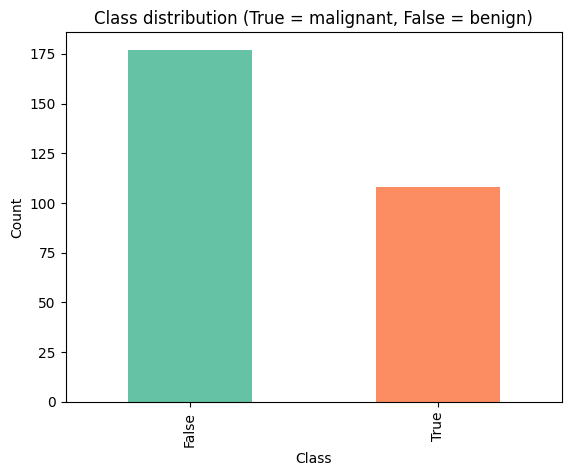

In [24]:
# --- Step 4: Target distribution (corrected for your dataset) ---

target_col = "class"   # ✅ correct column name
print(df_train[target_col].value_counts())
print()
print(df_train[target_col].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt

df_train[target_col].value_counts().plot(kind="bar", color=["#66c2a5", "#fc8d62"])
plt.title("Class distribution (True = malignant, False = benign)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


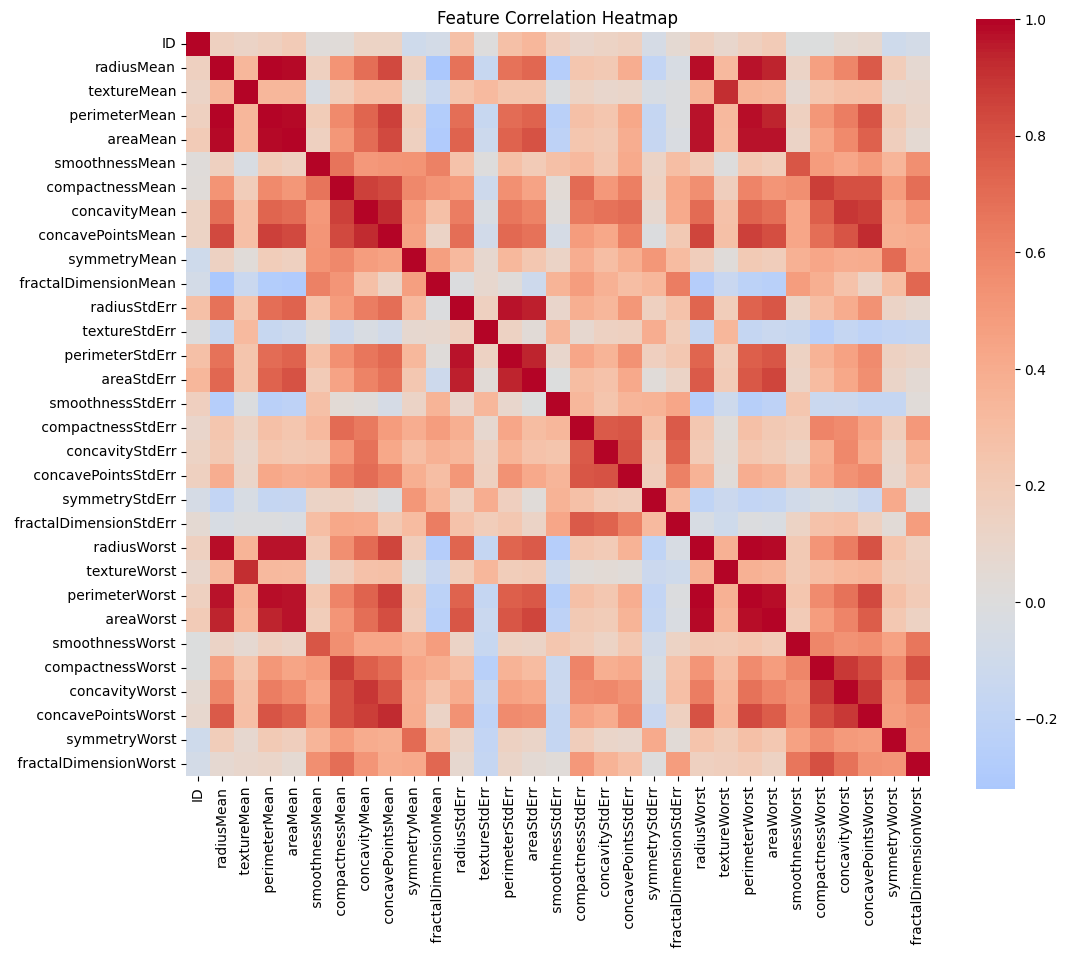

In [18]:
numeric_cols = df_train.select_dtypes("number").columns.tolist()
corr = df_train[numeric_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.show()


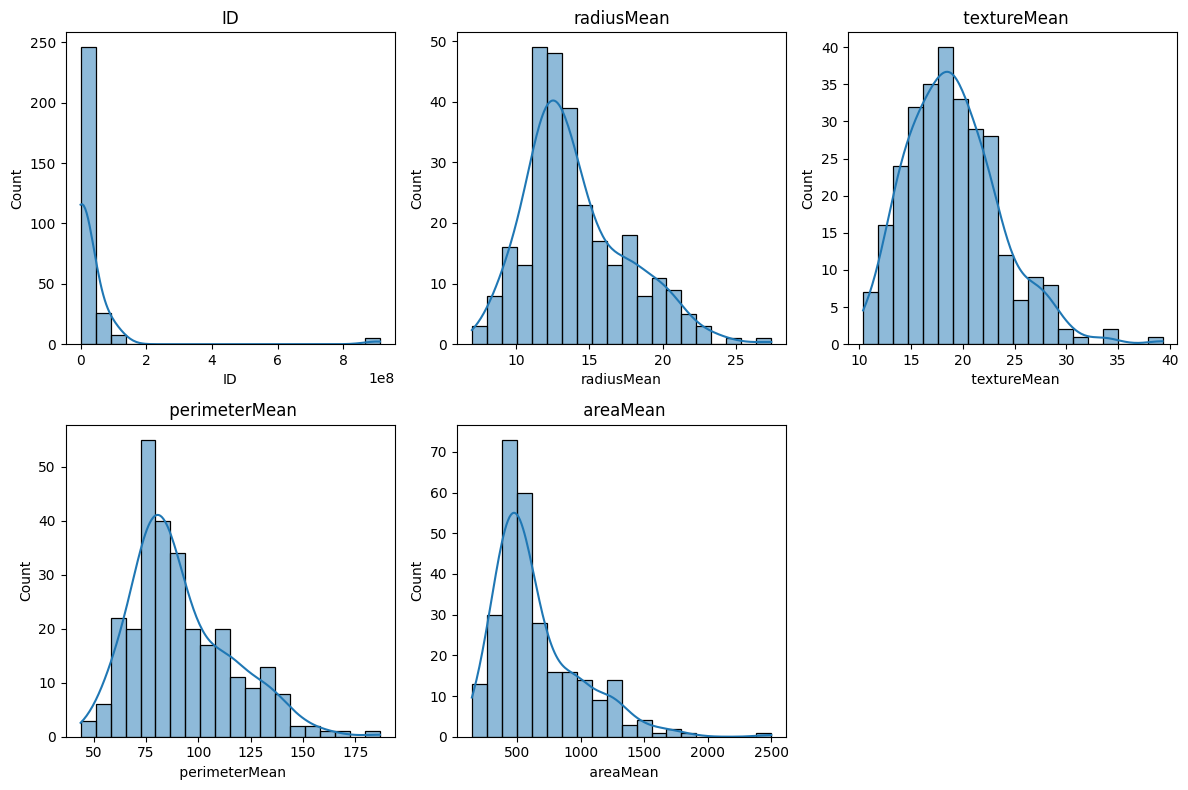

In [19]:

numeric_cols = df_train.select_dtypes("number").columns.tolist()

# Take a few representative features
sample_features = numeric_cols[:5]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
for i, col in enumerate(sample_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], bins=20, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

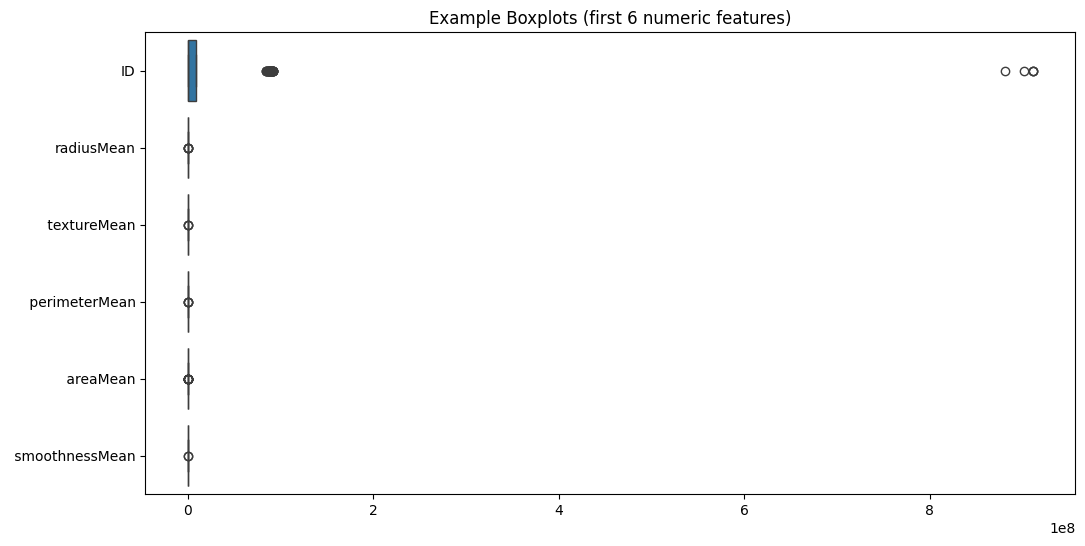

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_train[numeric_cols[:6]], orient="h")
plt.title("Example Boxplots (first 6 numeric features)")
plt.show()

In [25]:
df_train.groupby("class").mean().T.sort_values(by=True, ascending=False).head(10)

class,False,True
ID,2.100927e+07,4.107989e+07
areaWorst,5.531876e+02,1.410929e+03
areaMean,4.580395e+02,9.635935e+02
perimeterWorst,8.658718e+01,1.401012e+02
perimeterMean,7.762435e+01,1.143859e+02
areaStdErr,2.141301e+01,6.896583e+01
textureWorst,2.320079e+01,2.944954e+01
textureMean,1.762768e+01,2.155574e+01
radiusWorst,1.330515e+01,2.098222e+01
radiusMean,1.207459e+01,1.733676e+01


ValueError: Could not interpret value `areaMean` for `y`. An entry with this name does not appear in `data`.

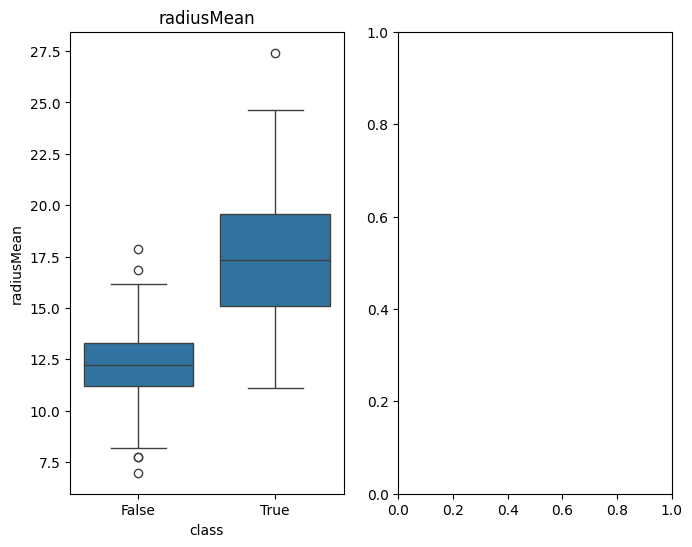

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = ["radiusMean", "areaMean", "compactnessMean"]
plt.figure(figsize=(12,6))
for i, col in enumerate(top_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x="class", y=col, data=df_train)
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
def load_datasets(
    train_path: str,
    test_path: str,
    solution_example_path: Optional[str] = None,
    id_col_candidates: Tuple[str, ...] = ("id", "ID", "Id")
) -> Tuple[pd.DataFrame, pd.DataFrame, Optional[pd.DataFrame], Optional[str]]:
    """
    Load the provided CSVs. Try to infer an ID column name if present.
    Returns: (df_train, df_test, df_solution_example, inferred_id_col)
    """
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    df_sol = pd.read_csv(solution_example_path) if solution_example_path else None

    inferred_id = None
    for c in id_col_candidates:
        if c in df_train.columns:
            inferred_id = c
            break
        if c in df_test.columns:
            inferred_id = c
            break

    return df_train, df_test, df_sol, inferred_id

In [ ]:
def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Return a compact summary: dtype, #nulls, %nulls, nunique, example values."""
    n = len(df)
    summary = []
    for col in df.columns:
        nulls = df[col].isna().sum()
        summary.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "nulls": int(nulls),
            "null_%": round(100 * nulls / max(n, 1), 3),
            "nunique": int(df[col].nunique()),
            "example": df[col].iloc[0] if n > 0 else None
        })
    return pd.DataFrame(summary)


In [ ]:
def class_balance(y: pd.Series) -> pd.DataFrame:
    """Return class counts and percentages for a target vector."""
    counts = y.value_counts(dropna=False).rename("count")
    pct = (100 * counts / counts.sum()).rename("percent")
    return pd.concat([counts, pct], axis=1).reset_index().rename(columns={"index": "class"})



In [ ]:
@dataclass
class PreprocessConfig:
    id_col: Optional[str] = None
    target_col: str = "diagnosis"          # common label for Breast Cancer Diagnostic is 'diagnosis' (M/B)
    positive_label: str = "M"              # malignant
    negative_label: str = "B"              # benign
    drop_constant: bool = True
    zscore_clip: Optional[float] = 5.0     # clip extreme z-scores; set None to disable


def infer_target_column(df: pd.DataFrame, candidates: Tuple[str, ...] = ("diagnosis", "label", "class", "target")) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def make_preprocess_pipeline(numeric_features: List[str]) -> ColumnTransformer:
    """
    Numeric pipeline: impute (median) -> scale (StandardScaler)
    (Breast cancer dataset is numeric-heavy; no categorical features expected.)
    """
    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    return ColumnTransformer(
        transformers=[("num", num_pipe, numeric_features)],
        remainder="drop"
    )


def apply_basic_cleaning(
    df: pd.DataFrame,
    config: PreprocessConfig
) -> Tuple[pd.DataFrame, Optional[pd.Series]]:
    """
    - Drop ID column (if present)
    - Convert target M/B -> 1/0 (if present)
    - Drop constant columns (optional)
    - Optional robust z-score clipping for numeric columns to limit extreme outliers
    Returns: (clean_df, y_if_present)
    """
    df = df.copy()

    # Handle ID column
    if config.id_col and config.id_col in df.columns:
        df.drop(columns=[config.id_col], inplace=True)

    # Detect target if not specified
    target = config.target_col if config.target_col in df.columns else infer_target_column(df)
    y = None
    if target and target in df.columns:
        y_raw = df[target]
        # map labels if they are strings M/B or similar
        if y_raw.dtype == object:
            mapper = {
                config.positive_label: 1,
                config.negative_label: 0
            }
            # fallback: try common lowercase variants
            mapper.update({str(config.positive_label).lower(): 1, str(config.negative_label).lower(): 0})
            y = y_raw.map(mapper)
            # if mapping failed (NaNs), fallback: try binary factorization
            if y.isna().any():
                y = pd.Series(pd.Categorical(y_raw).codes, index=y_raw.index)
        else:
            y = y_raw.astype(int)
        df.drop(columns=[target], inplace=True)

    # Drop constant columns
    if config.drop_constant:
        nunique = df.nunique(dropna=False)
        const_cols = nunique[nunique <= 1].index.tolist()
        if const_cols:
            df.drop(columns=const_cols, inplace=True)

    # Z-score clipping (robust to scale later)
    if config.zscore_clip is not None and config.zscore_clip > 0:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) > 0:
            # Compute z-scores
            means = df[numeric_cols].mean()
            stds = df[numeric_cols].std(ddof=0).replace(0, np.nan)
            z = (df[numeric_cols] - means) / stds
            z = z.clip(lower=-config.zscore_clip, upper=config.zscore_clip)
            df[numeric_cols] = z * stds.fillna(1.0) + means

    return df, y
